# Итоговая контрольная работа: многомерный временной ряд

**Тема:** анализ и прогнозирование многомерного временного ряда с использованием классических методов машинного обучения и нейронных сетей.

**Задача:** построить полный pipeline анализа многомерного временного ряда: загрузка данных, EDA, проверка стационарности, предобработка, извлечение признаков, обучение моделей, сравнение метрик и формулировка выводов.

В работе используется промышленный датасет **Steel Industry Energy Consumption**. Решается задача регрессии: прогноз энергопотребления сталелитейного производства `Usage_kWh` на следующий час.

## 1. Подготовка окружения

В Google Colab TensorFlow обычно уже установлен. Если `tensorflow` или `statsmodels` отсутствуют, они будут установлены автоматически.

In [1]:
import importlib.util
import subprocess
import sys

for package in ["tensorflow", "statsmodels"]:
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

In [2]:
import io
import os
import random
import warnings
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller
import tensorflow as tf
from tensorflow.keras import callbacks, layers, models

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## 2. Датасет

**Источник:** UCI Machine Learning Repository, датасет `Steel Industry Energy Consumption`.

Датасет подходит для поставленной задачи по следующим причинам:

- есть временная метка `date`;
- есть больше трех признаков, изменяющихся во времени;
- данные описывают реальный промышленный процесс энергопотребления;
- в данных присутствуют числовые и категориальные признаки, поэтому можно выполнить интерполяцию, кодирование категорий, анализ сезонности, автокорреляции и прогнозирование.

Исходные признаки включают энергопотребление, реактивную мощность, выбросы CO2, коэффициенты мощности, время в секундах от начала суток, статус дня недели, день недели и тип нагрузки.

In [3]:
DATA_URL = "https://archive.ics.uci.edu/static/public/851/steel+industry+energy+consumption.zip"
TARGET = "Usage_kWh"
DATETIME_COL = "date"
TEST_SIZE = 24 * 14      # последние 14 дней по часам
LOOKBACK = 48            # 48 часов истории для нейросетей
HIST_WINDOW = 168        # неделя истории для feature extraction

response = requests.get(DATA_URL, timeout=60)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
    csv_name = [name for name in zf.namelist() if name.lower().endswith(".csv")][0]
    with zf.open(csv_name) as f:
        raw = pd.read_csv(f)

# В файле встречается BOM в названии первой колонки.
raw.columns = raw.columns.str.replace("\ufeff", "", regex=False)
raw[DATETIME_COL] = pd.to_datetime(raw[DATETIME_COL], dayfirst=True)
raw = raw.sort_values(DATETIME_COL).drop_duplicates(DATETIME_COL).set_index(DATETIME_COL)

print("Исходный размер:", raw.shape)
print("Период:", raw.index.min(), "-", raw.index.max())
print("Шаг в исходных данных: 15 минут")
print("Колонки:")
print(list(raw.columns))
display(raw.head())
display(raw.isna().sum().to_frame("missing_count"))

Исходный размер: (35040, 10)
Период: 2018-01-01 00:00:00 - 2018-12-31 23:45:00
Шаг в исходных данных: 15 минут
Колонки:
['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
date,,,,,,,,,,
2018-01-01 00:00:00,3.42,3.46,0.0,0.0,70.30,100.0,0,Weekday,Monday,Light_Load
2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load


,missing_count
Usage_kWh,0
Lagging_Current_Reactive.Power_kVarh,0
Leading_Current_Reactive_Power_kVarh,0
CO2(tCO2),0
Lagging_Current_Power_Factor,0
Leading_Current_Power_Factor,0
NSM,0
WeekStatus,0
Day_of_week,0
Load_Type,0


## 3. Предобработка

Чтобы ноутбук быстрее выполнялся в Colab и графики были читаемыми, 15-минутные данные агрегируются до **часовой частоты**:

- числовые признаки усредняются;
- категориальные признаки берутся по моде внутри часа;
- возможные пропуски восстанавливаются временной интерполяцией и `ffill/bfill`;
- категориальные признаки кодируются через one-hot encoding.

In [4]:
def mode_or_nan(values):
    modes = values.mode(dropna=True)
    return modes.iloc[0] if len(modes) else np.nan

numeric_cols = raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [col for col in raw.columns if col not in numeric_cols]

hourly_numeric = raw[numeric_cols].resample("H").mean()
hourly_categorical = raw[categorical_cols].resample("H").agg(mode_or_nan)

hourly = pd.concat([hourly_numeric, hourly_categorical], axis=1)
hourly[numeric_cols] = hourly[numeric_cols].interpolate("time").ffill().bfill()
hourly[categorical_cols] = hourly[categorical_cols].ffill().bfill()

# Явные календарные признаки. Они полезны для суточной/недельной сезонности.
hourly["hour"] = hourly.index.hour
hourly["dayofweek"] = hourly.index.dayofweek
hourly["is_weekend"] = (hourly.index.dayofweek >= 5).astype(int)
hourly["hour_sin"] = np.sin(2 * np.pi * hourly["hour"] / 24)
hourly["hour_cos"] = np.cos(2 * np.pi * hourly["hour"] / 24)
hourly["dow_sin"] = np.sin(2 * np.pi * hourly["dayofweek"] / 7)
hourly["dow_cos"] = np.cos(2 * np.pi * hourly["dayofweek"] / 7)

encoded = pd.get_dummies(hourly, columns=categorical_cols, drop_first=False, dtype=int)
encoded = encoded.replace([np.inf, -np.inf], np.nan).dropna()

print("Размер после агрегации до часов:", hourly.shape)
print("Размер после encoding:", encoded.shape)
print("Числовые признаки:", numeric_cols)
print("Категориальные признаки:", categorical_cols)
display(hourly.head())
display(encoded.head())

Размер после агрегации до часов: (8760, 17)
Размер после encoding: (8760, 26)
Числовые признаки: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM']
Категориальные признаки: ['WeekStatus', 'Day_of_week', 'Load_Type']


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,hour,dayofweek,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos
date,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,3.4575,3.5375,0.0,0.0,70.1400,100.0,1350.0,Weekday,Monday,Light_Load,0,0,0,0.000000,1.000000,0.0,1.0
2018-01-01 01:00:00,3.5025,3.9400,0.0,0.0,66.5475,100.0,4950.0,Weekday,Monday,Light_Load,1,0,0,0.258819,0.965926,0.0,1.0
2018-01-01 02:00:00,3.5300,4.1675,0.0,0.0,64.7400,100.0,8550.0,Weekday,Monday,Light_Load,2,0,0,0.500000,0.866025,0.0,1.0
2018-01-01 03:00:00,3.4550,4.0500,0.0,0.0,65.0675,100.0,12150.0,Weekday,Monday,Light_Load,3,0,0,0.707107,0.707107,0.0,1.0
2018-01-01 04:00:00,3.6175,4.4100,0.0,0.0,63.5175,100.0,15750.0,Weekday,Monday,Light_Load,4,0,0,0.866025,0.500000,0.0,1.0


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,hour,dayofweek,is_weekend,...,Day_of_week_Friday,Day_of_week_Monday,Day_of_week_Saturday,Day_of_week_Sunday,Day_of_week_Thursday,Day_of_week_Tuesday,Day_of_week_Wednesday,Load_Type_Light_Load,Load_Type_Maximum_Load,Load_Type_Medium_Load
date,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,3.4575,3.5375,0.0,0.0,70.1400,100.0,1350.0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
2018-01-01 01:00:00,3.5025,3.9400,0.0,0.0,66.5475,100.0,4950.0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
2018-01-01 02:00:00,3.5300,4.1675,0.0,0.0,64.7400,100.0,8550.0,2,0,0,...,0,1,0,0,0,0,0,1,0,0
2018-01-01 03:00:00,3.4550,4.0500,0.0,0.0,65.0675,100.0,12150.0,3,0,0,...,0,1,0,0,0,0,0,1,0,0
2018-01-01 04:00:00,3.6175,4.4100,0.0,0.0,63.5175,100.0,15750.0,4,0,0,...,0,1,0,0,0,0,0,1,0,0


## 4. EDA: визуализация, тренд, стационарность, сезонность, автокорреляция, выбросы

Сначала посмотрим общий вид ряда и отдельный фрагмент за первые две недели.

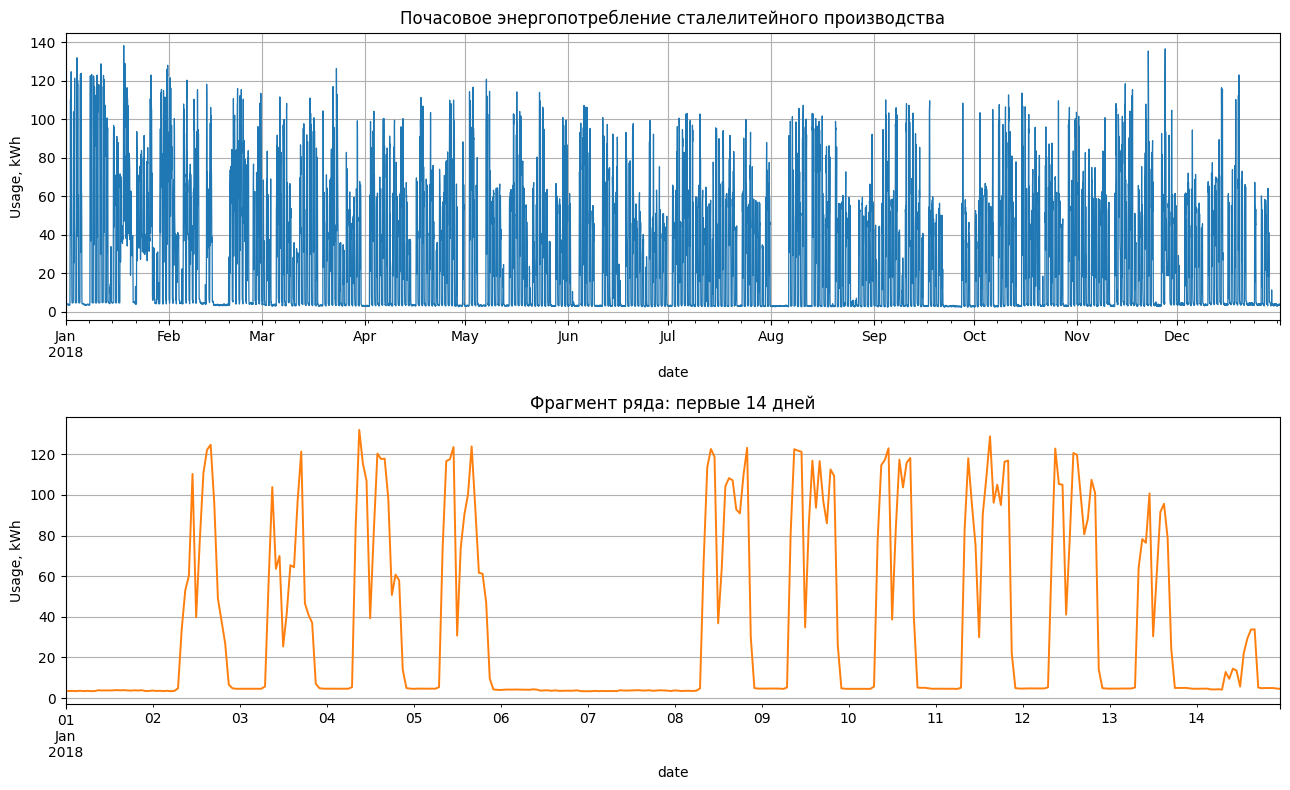

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

hourly[TARGET].plot(ax=axes[0], linewidth=0.9)
axes[0].set_title("Почасовое энергопотребление сталелитейного производства")
axes[0].set_ylabel("Usage, kWh")

hourly[TARGET].iloc[:24 * 14].plot(ax=axes[1], linewidth=1.4, color="tab:orange")
axes[1].set_title("Фрагмент ряда: первые 14 дней")
axes[1].set_ylabel("Usage, kWh")

plt.tight_layout()
plt.show()

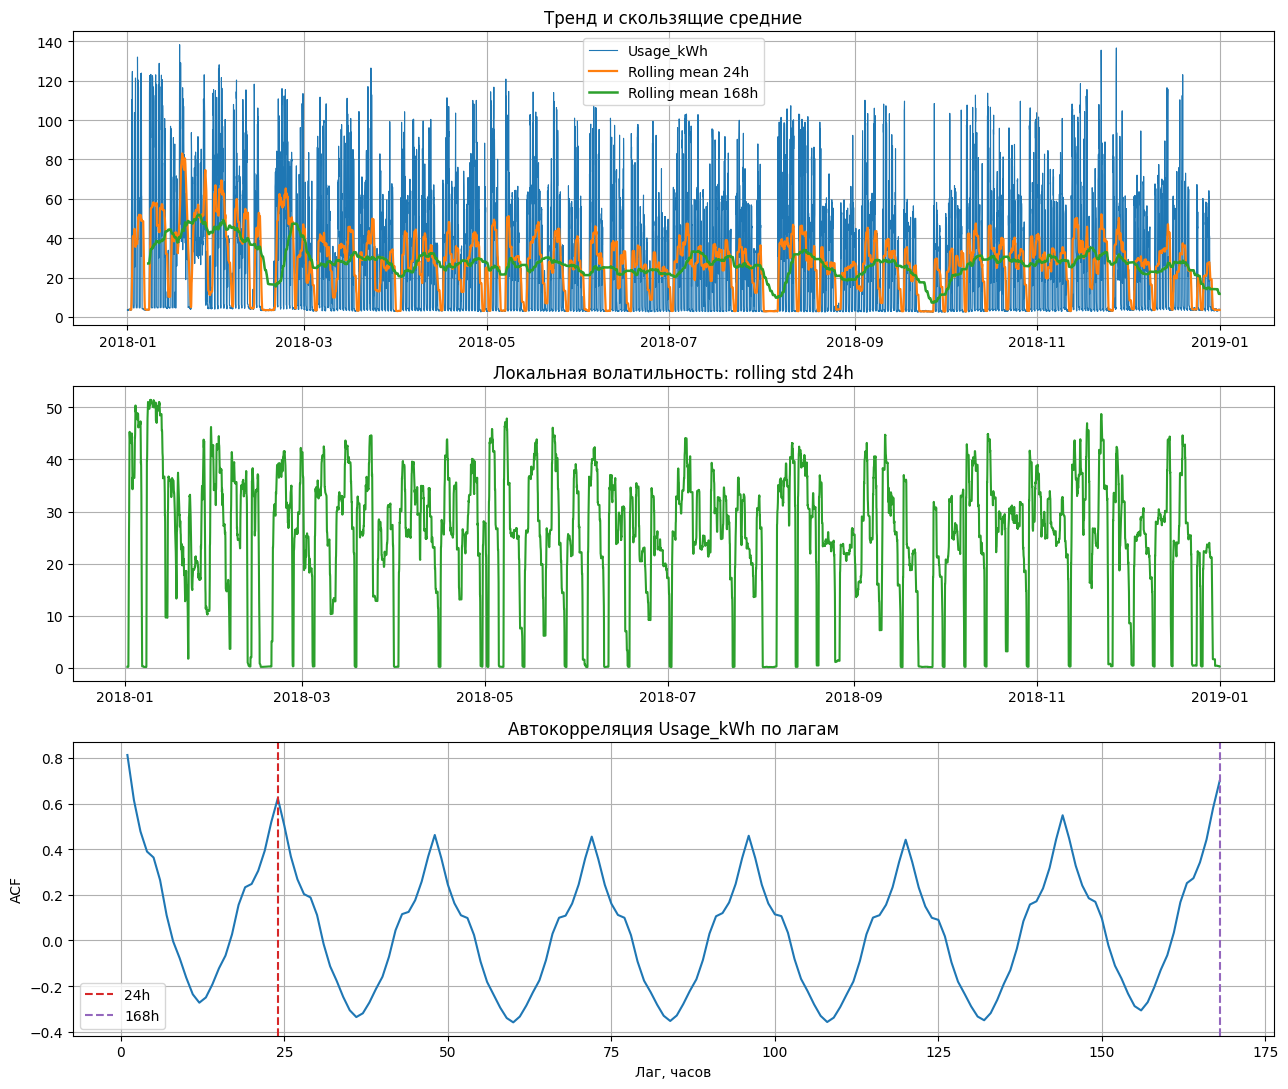

In [6]:
usage = hourly[TARGET]
rolling_24 = usage.rolling(24).mean()
rolling_168 = usage.rolling(168).mean()
rolling_std_24 = usage.rolling(24).std()

fig, axes = plt.subplots(3, 1, figsize=(13, 11))

axes[0].plot(usage.index, usage, label="Usage_kWh", linewidth=0.8)
axes[0].plot(rolling_24.index, rolling_24, label="Rolling mean 24h", linewidth=1.6)
axes[0].plot(rolling_168.index, rolling_168, label="Rolling mean 168h", linewidth=1.8)
axes[0].set_title("Тренд и скользящие средние")
axes[0].legend()

axes[1].plot(rolling_std_24.index, rolling_std_24, color="tab:green")
axes[1].set_title("Локальная волатильность: rolling std 24h")

lags = np.arange(1, 24 * 7 + 1)
autocorr = [usage.autocorr(lag=int(lag)) for lag in lags]
axes[2].plot(lags, autocorr)
axes[2].axvline(24, color="tab:red", linestyle="--", label="24h")
axes[2].axvline(168, color="tab:purple", linestyle="--", label="168h")
axes[2].set_title("Автокорреляция Usage_kWh по лагам")
axes[2].set_xlabel("Лаг, часов")
axes[2].set_ylabel("ACF")
axes[2].legend()

plt.tight_layout()
plt.show()

In [7]:
def adf_summary(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "series": name,
        "ADF statistic": result[0],
        "p-value": result[1],
        "stationary at 5%": "да" if result[1] < 0.05 else "нет",
    }

stationarity_table = pd.DataFrame([
    adf_summary(usage, "Usage_kWh"),
    adf_summary(usage.diff(), "Usage_kWh diff(1)"),
])
display(stationarity_table)

first_half = usage.iloc[: len(usage) // 2]
second_half = usage.iloc[len(usage) // 2 :]
print(f"Среднее в первой половине: {first_half.mean():.3f}")
print(f"Среднее во второй половине: {second_half.mean():.3f}")
print(f"Дисперсия в первой половине: {first_half.var():.3f}")
print(f"Дисперсия во второй половине: {second_half.var():.3f}")

,series,ADF statistic,p-value,stationary at 5%
0,Usage_kWh,-12.693525,1.118798e-23,да
1,Usage_kWh diff(1),-20.698166,0.000000e+00,да


Среднее в первой половине: 29.819
Среднее во второй половине: 24.955
Дисперсия в первой половине: 1090.239
Дисперсия во второй половине: 864.130


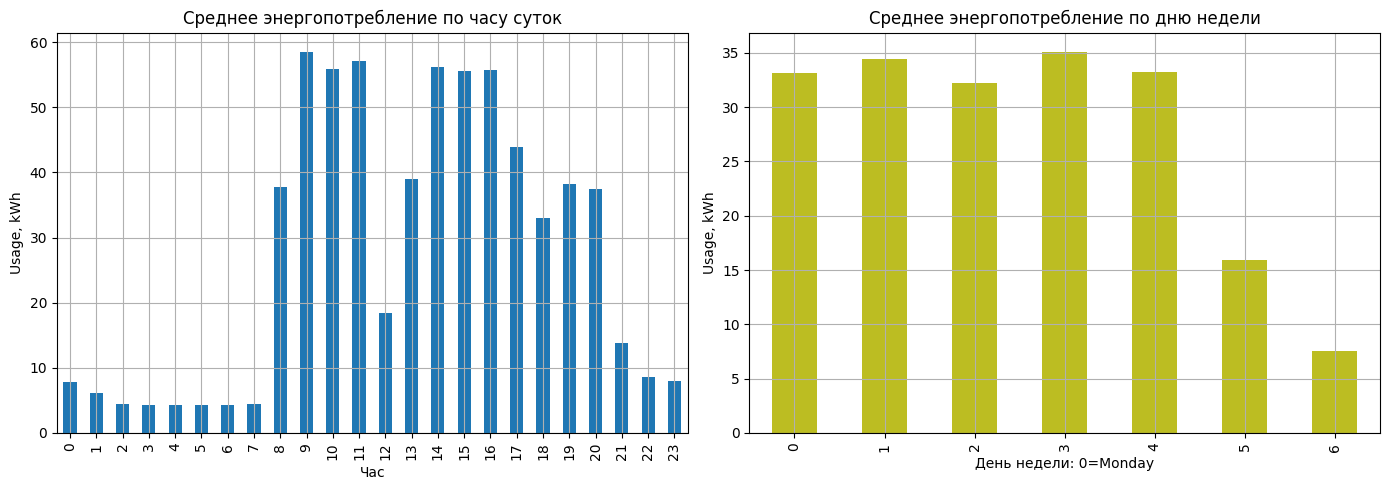

IQR границы выбросов: -68.321 122.529
Количество выбросов по Usage_kWh: 23


,Usage_kWh_outlier
date,
2018-01-02 16:00:00,124.7325
2018-01-04 09:00:00,132.0200
2018-01-05 11:00:00,123.6150
2018-01-05 16:00:00,123.8950
2018-01-08 10:00:00,122.6350
2018-01-08 20:00:00,123.2100
2018-01-09 09:00:00,122.5350
2018-01-10 11:00:00,123.0025
2018-01-11 15:00:00,128.8500


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly.groupby("hour")[TARGET].mean().plot(kind="bar", ax=axes[0], color="tab:blue")
axes[0].set_title("Среднее энергопотребление по часу суток")
axes[0].set_xlabel("Час")
axes[0].set_ylabel("Usage, kWh")

hourly.groupby("dayofweek")[TARGET].mean().plot(kind="bar", ax=axes[1], color="tab:olive")
axes[1].set_title("Среднее энергопотребление по дню недели")
axes[1].set_xlabel("День недели: 0=Monday")
axes[1].set_ylabel("Usage, kWh")

plt.tight_layout()
plt.show()

q1, q3 = usage.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = usage[(usage < lower) | (usage > upper)]
print("IQR границы выбросов:", round(lower, 3), round(upper, 3))
print("Количество выбросов по Usage_kWh:", len(outliers))
display(outliers.to_frame("Usage_kWh_outlier").head(20))

## 5. Feature extraction

По заданию нужно не меньше трех методов извлечения признаков из временного ряда. Здесь используются четыре группы:

1. **Lag features:** значения признаков в прошлые часы.
2. **Rolling statistics:** среднее и стандартное отклонение в скользящих окнах.
3. **Статистические признаки окна:** минимум, максимум, размах, квантили и линейный тренд.
4. **FFT-признаки:** спектральная энергия и максимальная амплитуда.

Для каждого момента времени признаки строятся только по прошлому, поэтому утечки будущего нет.

In [9]:
# Признаки, для которых строим временные лаги и статистики.
BASE_NUMERIC_FEATURES = [
    "Usage_kWh",
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "CO2(tCO2)",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor",
]

# Текущие one-hot и календарные признаки добавим как обычные exogenous features.
CURRENT_EXOG_FEATURES = [col for col in encoded.columns if col not in BASE_NUMERIC_FEATURES]
LAGS = [1, 2, 3, 6, 12, 24, 48, 168]
ROLL_WINDOWS = [6, 24, 168]
START_INDEX = max(max(LAGS), HIST_WINDOW)


def build_feature_table(data, target=TARGET):
    rows = []
    for i in range(START_INDEX, len(data) - 1):
        row = {
            "Date": data.index[i],
            "target_next": data[target].iloc[i + 1],
            "current_target": data[target].iloc[i],
        }

        # Текущие календарные и закодированные категориальные признаки.
        for col in CURRENT_EXOG_FEATURES:
            row[f"current_{col}"] = data[col].iloc[i]

        # 1) Lag features.
        for col in BASE_NUMERIC_FEATURES:
            for lag in LAGS:
                row[f"{col}_lag_{lag}"] = data[col].iloc[i - lag]

        # 2) Rolling statistics.
        for col in BASE_NUMERIC_FEATURES:
            for window in ROLL_WINDOWS:
                values = data[col].iloc[i - window : i]
                row[f"{col}_roll_mean_{window}"] = values.mean()
                row[f"{col}_roll_std_{window}"] = values.std()

        # 3) Statistical features over one week.
        for col in BASE_NUMERIC_FEATURES:
            values = data[col].iloc[i - HIST_WINDOW : i]
            row[f"{col}_min_{HIST_WINDOW}"] = values.min()
            row[f"{col}_max_{HIST_WINDOW}"] = values.max()
            row[f"{col}_range_{HIST_WINDOW}"] = values.max() - values.min()
            row[f"{col}_q25_{HIST_WINDOW}"] = values.quantile(0.25)
            row[f"{col}_q75_{HIST_WINDOW}"] = values.quantile(0.75)
            row[f"{col}_trend_{HIST_WINDOW}"] = np.polyfit(np.arange(HIST_WINDOW), values, 1)[0]

        # 4) FFT features.
        for col in BASE_NUMERIC_FEATURES:
            values = data[col].iloc[i - HIST_WINDOW : i].to_numpy()
            centered = values - values.mean()
            fft = np.abs(np.fft.rfft(centered))
            row[f"{col}_fft_energy"] = float(np.sum(fft[1:] ** 2))
            row[f"{col}_fft_max_amp"] = float(np.max(fft[1:])) if len(fft) > 1 else 0.0

        rows.append(row)

    feature_table = pd.DataFrame(rows).set_index("Date")
    return feature_table.replace([np.inf, -np.inf], np.nan).dropna()

features_df = build_feature_table(encoded)
print("Размер таблицы признаков:", features_df.shape)
print("Количество признаков для модели:", features_df.shape[1] - 1)
display(features_df.head())

Размер таблицы признаков: (8591, 154)
Количество признаков для модели: 153


,target_next,current_target,current_NSM,current_hour,current_dayofweek,current_is_weekend,current_hour_sin,current_hour_cos,current_dow_sin,current_dow_cos,...,Lagging_Current_Reactive.Power_kVarh_fft_energy,Lagging_Current_Reactive.Power_kVarh_fft_max_amp,Leading_Current_Reactive_Power_kVarh_fft_energy,Leading_Current_Reactive_Power_kVarh_fft_max_amp,CO2(tCO2)_fft_energy,CO2(tCO2)_fft_max_amp,Lagging_Current_Power_Factor_fft_energy,Lagging_Current_Power_Factor_fft_max_amp,Leading_Current_Power_Factor_fft_energy,Leading_Current_Power_Factor_fft_max_amp
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-08 00:00:00,3.6375,3.7875,1350.0,0,0,0,0.000000,1.000000,0.0,1.0,...,3.356080e+06,874.443558,1.005884e+06,494.65487,4.05865,1.096584,2.897145e+06,1488.526205,1.569915e+07,1938.020146
2018-01-08 01:00:00,3.5000,3.6375,4950.0,1,0,0,0.258819,0.965926,0.0,1.0,...,3.354903e+06,873.498849,1.005884e+06,494.65487,4.05865,1.096584,2.915894e+06,1492.655649,1.569915e+07,1938.020146
2018-01-08 02:00:00,3.5900,3.5000,8550.0,2,0,0,0.500000,0.866025,0.0,1.0,...,3.353736e+06,872.427872,1.005884e+06,494.65487,4.05865,1.096584,2.943881e+06,1499.174662,1.569915e+07,1938.020146
2018-01-08 03:00:00,3.5825,3.5900,12150.0,3,0,0,0.707107,0.707107,0.0,1.0,...,3.352867e+06,871.690156,1.005884e+06,494.65487,4.05865,1.096584,2.970328e+06,1505.499295,1.569915e+07,1938.020146
2018-01-08 04:00:00,3.5175,3.5825,15750.0,4,0,0,0.866025,0.500000,0.0,1.0,...,3.351655e+06,870.576750,1.005884e+06,494.65487,4.05865,1.096584,3.002707e+06,1513.787354,1.569915e+07,1938.020146


## 6. Train/test split и масштабирование

Временной ряд нельзя перемешивать. Последние 14 дней оставлены для теста, предыдущие наблюдения - для обучения.

In [10]:
train_df = features_df.iloc[:-TEST_SIZE]
test_df = features_df.iloc[-TEST_SIZE:]

X_train = train_df.drop(columns=["target_next"])
y_train = train_df["target_next"]
X_test = test_df.drop(columns=["target_next"])
y_test = test_df["target_next"]

x_scaler_tabular = StandardScaler()
X_train_scaled = x_scaler_tabular.fit_transform(X_train)
X_test_scaled = x_scaler_tabular.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.to_numpy().reshape(-1, 1)).ravel()

print("Train period:", train_df.index.min(), "-", train_df.index.max(), train_df.shape)
print("Test period:", test_df.index.min(), "-", test_df.index.max(), test_df.shape)

Train period: 2018-01-08 00:00:00 - 2018-12-17 22:00:00 (8255, 154)
Test period: 2018-12-17 23:00:00 - 2018-12-31 22:00:00 (336, 154)


## 7. Классическая модель: Random Forest

Random Forest используется как классическая ML-модель. Он работает с табличной таблицей признаков после feature extraction.

In [11]:
rf = RandomForestRegressor(
    n_estimators=350,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

## 8. Нейросетевые архитектуры: CNN1D, LSTM, GRU

Для нейросетей данные подаются как последовательности: `samples x time_steps x features`. В каждом объекте 48 часов истории по всем числовым, календарным и one-hot признакам.

In [12]:
def make_sequences(data, lookback=LOOKBACK, target=TARGET):
    feature_cols = list(data.columns)
    values = data[feature_cols].to_numpy(dtype=float)
    target_values = data[target].to_numpy(dtype=float)

    X, y, dates = [], [], []
    for i in range(lookback, len(data) - 1):
        X.append(values[i - lookback + 1 : i + 1])
        y.append(target_values[i + 1])
        dates.append(data.index[i])
    return np.array(X), np.array(y), pd.Index(dates), feature_cols

X_seq, y_seq, seq_dates, seq_feature_cols = make_sequences(encoded)
X_seq_train_raw = X_seq[:-TEST_SIZE]
X_seq_test_raw = X_seq[-TEST_SIZE:]
y_seq_train = y_seq[:-TEST_SIZE]
y_seq_test = y_seq[-TEST_SIZE:]
seq_test_dates = seq_dates[-TEST_SIZE:]

seq_scaler = StandardScaler()
n_train, steps, n_features = X_seq_train_raw.shape
X_seq_train = seq_scaler.fit_transform(X_seq_train_raw.reshape(-1, n_features)).reshape(n_train, steps, n_features)
X_seq_test = seq_scaler.transform(X_seq_test_raw.reshape(-1, n_features)).reshape(X_seq_test_raw.shape[0], steps, n_features)

y_seq_scaler = StandardScaler()
y_seq_train_scaled = y_seq_scaler.fit_transform(y_seq_train.reshape(-1, 1)).ravel()

print("Sequence train shape:", X_seq_train.shape)
print("Sequence test shape:", X_seq_test.shape)
print("Тестовые даты совпадают:", test_df.index.equals(seq_test_dates))

Sequence train shape: (8375, 48, 26)
Sequence test shape: (336, 48, 26)
Тестовые даты совпадают: True


In [13]:
def build_cnn1d(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(filters=32, kernel_size=3, activation="relu", padding="causal"),
        layers.Conv1D(filters=16, kernel_size=3, activation="relu", padding="causal"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="mse", metrics=["mae"])
    return model


def build_lstm(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(32, dropout=0.1),
        layers.Dense(16, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="mse", metrics=["mae"])
    return model


def build_gru(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(32, dropout=0.1),
        layers.Dense(16, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="mse", metrics=["mae"])
    return model


def train_nn_model(name, builder):
    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE)
    model = builder((LOOKBACK, n_features))
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
    )
    history = model.fit(
        X_seq_train,
        y_seq_train_scaled,
        validation_split=0.2,
        epochs=80,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0,
        shuffle=False,
    )
    pred_scaled = model.predict(X_seq_test, verbose=0).ravel()
    pred = y_seq_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    print(f"{name}: epochs = {len(history.history['loss'])}, final val_loss = {history.history['val_loss'][-1]:.5f}")
    return model, history, pred

cnn_model, cnn_history, pred_cnn = train_nn_model("CNN1D", build_cnn1d)
lstm_model, lstm_history, pred_lstm = train_nn_model("LSTM", build_lstm)
gru_model, gru_history, pred_gru = train_nn_model("GRU", build_gru)

CNN1D: epochs = 61, final val_loss = 0.30016
LSTM: epochs = 49, final val_loss = 0.12818
GRU: epochs = 39, final val_loss = 0.12190


## 9. Метрики и сравнение моделей

Используются четыре метрики:

- `MAE` - средняя абсолютная ошибка;
- `RMSE` - сильнее штрафует крупные ошибки;
- `MAPE` - средняя ошибка в процентах;
- `R2` - коэффициент детерминации.

По заданию достаточно двух метрик, но здесь их четыре.

In [14]:
predictions = {
    "Random Forest": pred_rf,
    "CNN1D": pred_cnn,
    "LSTM": pred_lstm,
    "GRU": pred_gru,
    "Naive baseline": test_df["current_target"].to_numpy(),
}


def compute_metrics(y_true, predictions):
    rows = []
    y_true = np.asarray(y_true)
    for name, pred in predictions.items():
        pred = np.asarray(pred)
        mae = mean_absolute_error(y_true, pred)
        rmse = mean_squared_error(y_true, pred) ** 0.5
        mape = np.mean(np.abs((y_true - pred) / np.maximum(np.abs(y_true), 1e-9))) * 100
        r2 = r2_score(y_true, pred)
        rows.append({"model": name, "MAE": mae, "RMSE": rmse, "MAPE_%": mape, "R2": r2})
    return pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)

metrics = compute_metrics(y_test, predictions)
display(metrics)
print("Лучшая модель по RMSE:", metrics.iloc[0]["model"])

,model,MAE,RMSE,MAPE_%,R2
0,Random Forest,3.822459,8.785039,39.283004,0.868882
1,GRU,4.680486,9.047641,66.769502,0.860926
2,LSTM,4.520836,9.048641,55.292330,0.860895
3,Naive baseline,6.078177,14.231890,34.185199,0.655887
4,CNN1D,13.061943,17.771875,214.991027,0.463409


Лучшая модель по RMSE: Random Forest


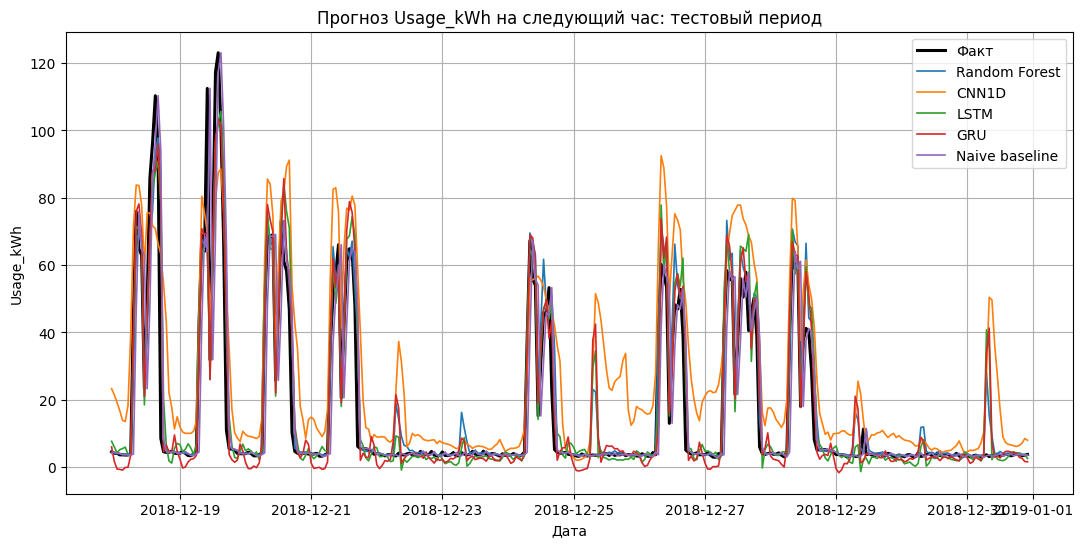

,actual,Random Forest,CNN1D,LSTM,GRU,Naive baseline
Date,,,,,,
2018-12-17 23:00:00,4.5450,4.446732,23.335329,7.687484,6.028419,4.1150
2018-12-18 00:00:00,4.1325,4.229890,21.458040,6.005914,1.714093,4.5450
2018-12-18 01:00:00,4.1575,4.098835,19.228403,4.305696,-0.553933,4.1325
2018-12-18 02:00:00,3.6550,3.965819,16.751245,5.202750,-0.639739,4.1575
2018-12-18 03:00:00,3.6725,3.814215,13.914988,5.520926,-0.858851,3.6550
2018-12-18 04:00:00,3.6000,3.868852,13.566511,5.970689,-0.078820,3.6725
2018-12-18 05:00:00,3.6175,3.850231,18.332041,3.818648,-0.017489,3.6000
2018-12-18 06:00:00,3.8975,3.929483,39.663521,3.513453,3.585923,3.6175
2018-12-18 07:00:00,46.2325,27.227307,71.388710,37.012009,41.488079,3.8975


In [15]:
plt.figure(figsize=(13, 6))
plt.plot(y_test.index, y_test.values, label="Факт", linewidth=2.2, color="black")
for name, pred in predictions.items():
    plt.plot(y_test.index, pred, label=name, linewidth=1.2)
plt.title("Прогноз Usage_kWh на следующий час: тестовый период")
plt.xlabel("Дата")
plt.ylabel("Usage_kWh")
plt.legend()
plt.show()

predictions_table = pd.DataFrame({"actual": y_test})
for name, pred in predictions.items():
    predictions_table[name] = pred

display(predictions_table.head(10))

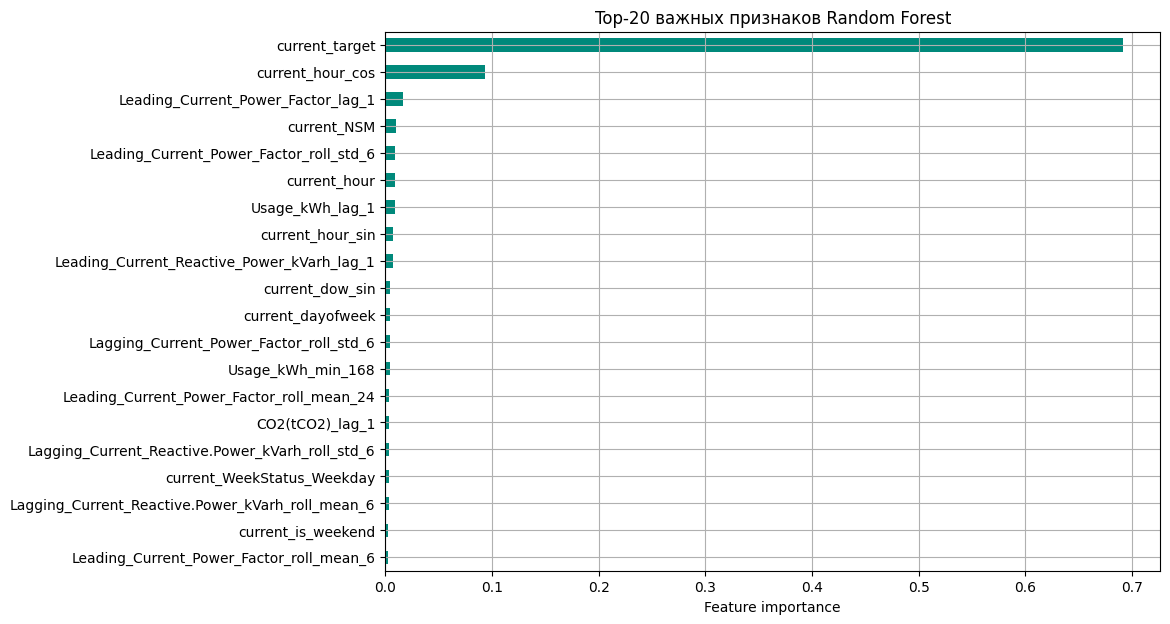

In [16]:
importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
importance.sort_values().plot(kind="barh", figsize=(10, 7), color="#00897B")
plt.title("Top-20 важных признаков Random Forest")
plt.xlabel("Feature importance")
plt.show()

## 10. Итоговые выводы

1. В работе использован промышленный датасет `Steel Industry Energy Consumption`, содержащий временной ряд энергопотребления сталелитейного производства.
2. Задача является регрессией: прогнозируется значение `Usage_kWh` на следующий час.
3. Данные являются многомерным временным рядом: есть временная метка и несколько признаков, изменяющихся во времени.
4. На этапе EDA рассмотрены график ряда, скользящие статистики, стационарность через ADF-тест, суточная и недельная сезонность, автокорреляция и выбросы.
5. Предобработка включает агрегацию до часовой частоты, интерполяцию пропусков, one-hot encoding категориальных признаков и масштабирование для нейросетевых моделей.
6. Реализованы четыре группы признаков: лаги, rolling statistics, статистики окна и FFT-признаки.
7. Обучены и сравнены модели `Random Forest`, `CNN1D`, `LSTM`, `GRU`; качество оценивается по `MAE`, `RMSE`, `MAPE`, `R2`.
8. Лучшая модель выбирается по минимальному `RMSE`, так как эта метрика сильнее штрафует крупные ошибки прогноза энергопотребления.
9. Различия в качестве моделей связаны с тем, что Random Forest использует заранее построенные табличные признаки, CNN1D выделяет локальные закономерности во временном окне, а LSTM и GRU учитывают порядок наблюдений.